# IMPORT LIBRARIES

In [1]:
# IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Advanced ML Pipeline Tools
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

import warnings
warnings.filterwarnings('ignore')

print("Libraries Imported. Visualization theme set to 'Muted'.")

Libraries Imported. Visualization theme set to 'Muted'.


# LOAD DATASET

In [2]:
# Loading the dataset
df = pd.read_csv("final_dataset_datasci.csv")

# Quick inspection of the first few rows and data types
print(f"Dataset Shape: {df.shape}")
display(df.head())

Dataset Shape: (839, 9)


,Listening_Date,Time,Track_Name,Genre,Valence,Energy,Mood_Now,Activity,Day_Rating
0,2025-12-01,3:01,Dominga,Indie,0.62,0.68,7,Commuting,7
1,2025-12-01,3:09,West,Indie,0.48,0.60,7,Working,7
2,2025-12-01,3:12,No Limit,Hip-Hop,0.71,0.82,7,Working,7
3,2025-12-01,3:16,No Limit,Hip-Hop,0.71,0.82,7,Working,7
4,2025-12-01,3:20,My Day,Indie,0.56,0.64,7,Working,7


In [3]:
# Overview of columns, data types, and missing values
df.info()

# Statistical summary
df.describe(include='all')

# Unique values per column
df.nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 839 entries, 0 to 838
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Listening_Date  839 non-null    object 
 1   Time            839 non-null    object 
 2   Track_Name      838 non-null    object 
 3   Genre           839 non-null    object 
 4   Valence         839 non-null    float64
 5   Energy          839 non-null    float64
 6   Mood_Now        839 non-null    int64  
 7   Activity        839 non-null    object 
 8   Day_Rating      839 non-null    int64  
dtypes: float64(2), int64(2), object(5)
memory usage: 59.1+ KB


,0
Listening_Date,69
Time,607
Track_Name,340
Genre,6
Valence,45
Energy,46
Mood_Now,5
Activity,14
Day_Rating,5


# DATA CLEANING AND PREPROCESSING

In [4]:
# Check missing values
df.isnull().sum()

,0
Listening_Date,0
Time,0
Track_Name,1
Genre,0
Valence,0
Energy,0
Mood_Now,0
Activity,0
Day_Rating,0


In [5]:
# Standardizing text (Removing extra spaces and title-casing genres)
df['Genre'] = df['Genre'].str.strip().str.title()
df['Activity'] = df['Activity'].str.strip().str.title()

In [6]:
# Removing rows with missing mood values
df.dropna(subset=['Mood_Now'], inplace=True)

In [7]:
# Feature Engineering: Time of Day
df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M').dt.hour
def categorize_time(hour):
    if 5 <= hour < 12: return 'Morning'
    elif 12 <= hour < 18: return 'Afternoon'
    elif 18 <= hour < 22: return 'Evening'
    else: return 'Late Night'
df['TimeOfDay'] = df['Hour'].apply(categorize_time)

In [8]:
# Target Creation: Categorizing Mood (1-4: Low, 5-7: Neutral, 8-10: High)
df['Mood_Category'] = pd.cut(df['Mood_Now'], bins=[0, 4, 7, 10], labels=['Low', 'Neutral', 'High'])

In [9]:
print(f"Unique Genres found: {df['Genre'].unique()}")

Unique Genres found: ['Indie' 'Hip-Hop' 'Pop' 'Rock' 'R&B']


# EXPLORATORY DATA ANALYSIS (EDA)

In [10]:
# CENTRAL TENDENCY & SUMMARY
print("--- SUMMARY STATISTICS (Numeric Metrics) ---")
# Providing Mean, Median, Std Dev, and Quartiles
stats_summary = df[['Valence', 'Energy', 'Mood_Now', 'Day_Rating']].describe()
display(stats_summary)

--- SUMMARY STATISTICS (Numeric Metrics) ---


,Valence,Energy,Mood_Now,Day_Rating
count,839.000000,839.000000,839.000000,839.000000
mean,0.545447,0.664684,5.438617,5.458880
std,0.122171,0.146992,1.083940,0.820626
min,0.180000,0.150000,4.000000,4.000000
25%,0.480000,0.550000,5.000000,5.000000
50%,0.520000,0.720000,5.000000,5.000000
75%,0.590000,0.750000,6.000000,6.000000
max,0.960000,0.950000,8.000000,9.000000


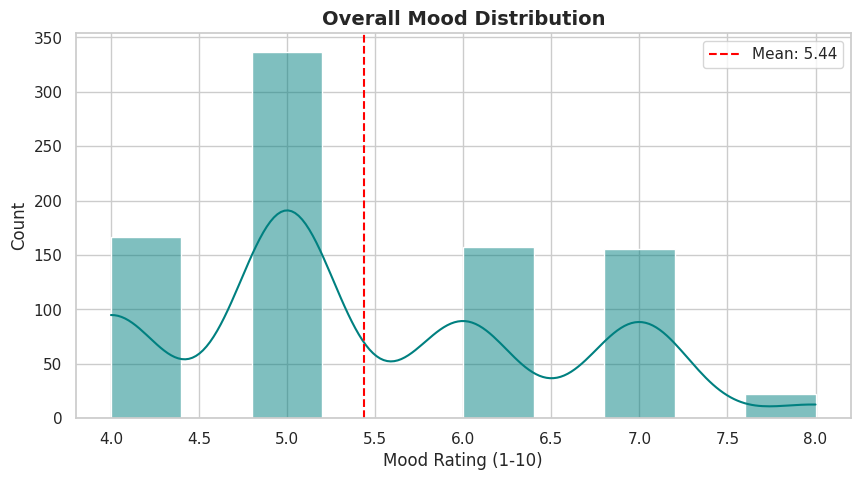

In [11]:
# MOOD DISTRIBUTION (Histogram)
# This shows if mood is generally positive, negative, or neutral
plt.figure(figsize=(10, 5))
sns.histplot(df['Mood_Now'], kde=True, color='teal', bins=10)
plt.axvline(df['Mood_Now'].mean(), color='red', linestyle='--', label=f"Mean: {df['Mood_Now'].mean():.2f}")
plt.title('Overall Mood Distribution', fontweight='bold', fontsize=14)
plt.xlabel('Mood Rating (1-10)')
plt.legend()
plt.show()

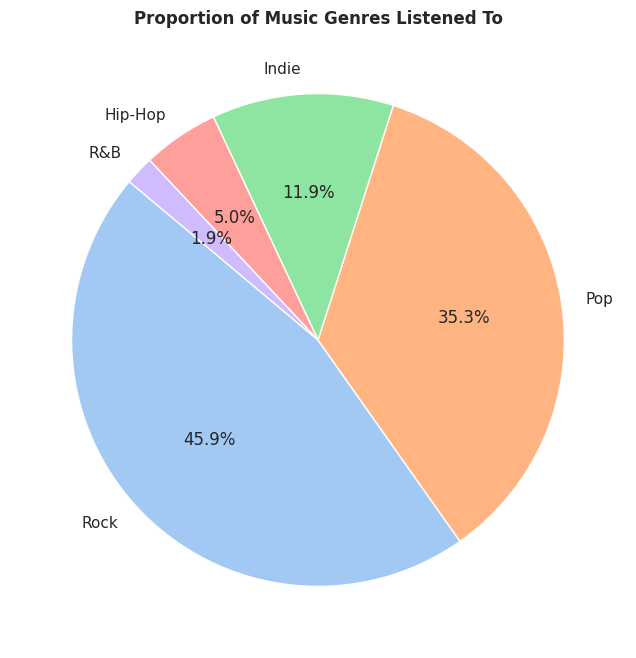

In [12]:
# GENRE PROPORTIONS (Pie Chart)
# Shows which of the 5 categories dominates listening time
plt.figure(figsize=(8, 8))
df['Genre'].value_counts().plot.pie(autopct='%1.1f%%', colors=sns.color_palette('pastel'), startangle=140)
plt.title('Proportion of Music Genres Listened To', fontweight='bold')
plt.ylabel('') # Hides the 'Genre' label on the side
plt.show()

Comparative Analysis (Categorical)

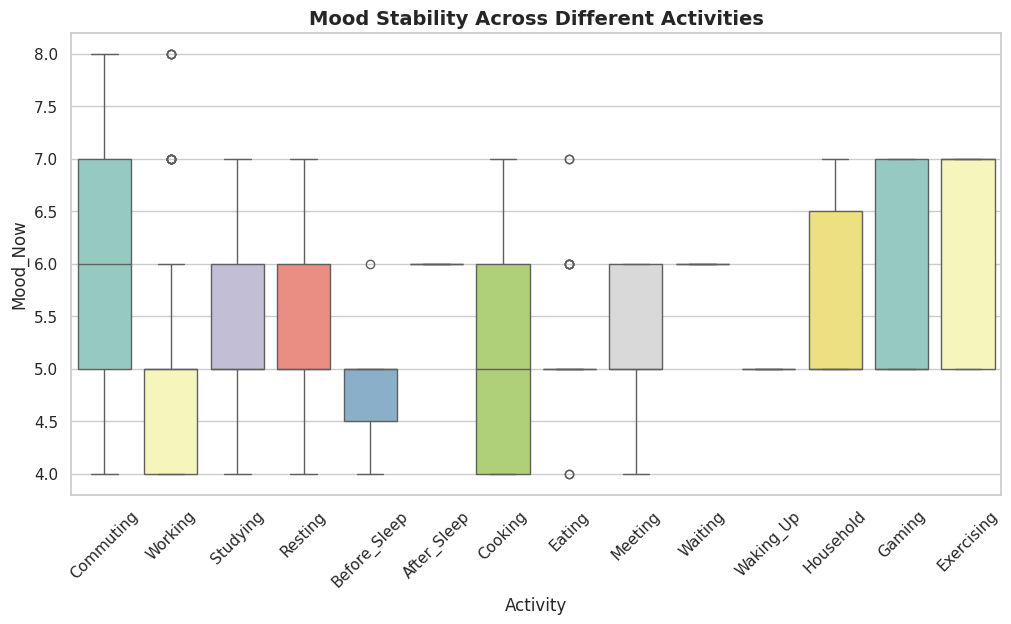

In [13]:
# MOOD BY ACTIVITY (Boxplot)
# Does 'Working' or 'Commuting' result in higher mood scores?
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Activity', y='Mood_Now', palette='Set3')
plt.title('Mood Stability Across Different Activities', fontweight='bold', fontsize=14)
plt.xticks(rotation=45)
plt.show()

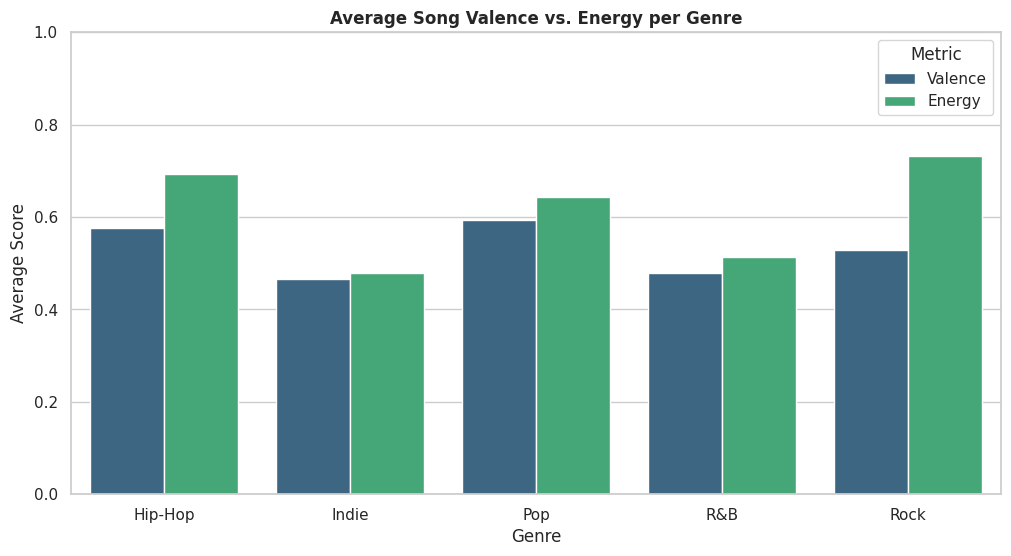

In [15]:
# VALENCE & ENERGY BY GENRE (Grouped Bar Chart)
# Comparing the technical attributes of the 5 genre categories
genre_metrics = df.groupby('Genre')[['Valence', 'Energy']].mean().reset_index()
genre_metrics_melted = genre_metrics.melt(id_vars='Genre', var_name='Metric', value_name='Average Score')

plt.figure(figsize=(12, 6))
sns.barplot(data=genre_metrics_melted, x='Genre', y='Average Score', hue='Metric', palette='viridis')
plt.title('Average Song Valence vs. Energy per Genre', fontweight='bold')
plt.ylim(0, 1.0)
plt.show()

Time-Series and Trend Analysis

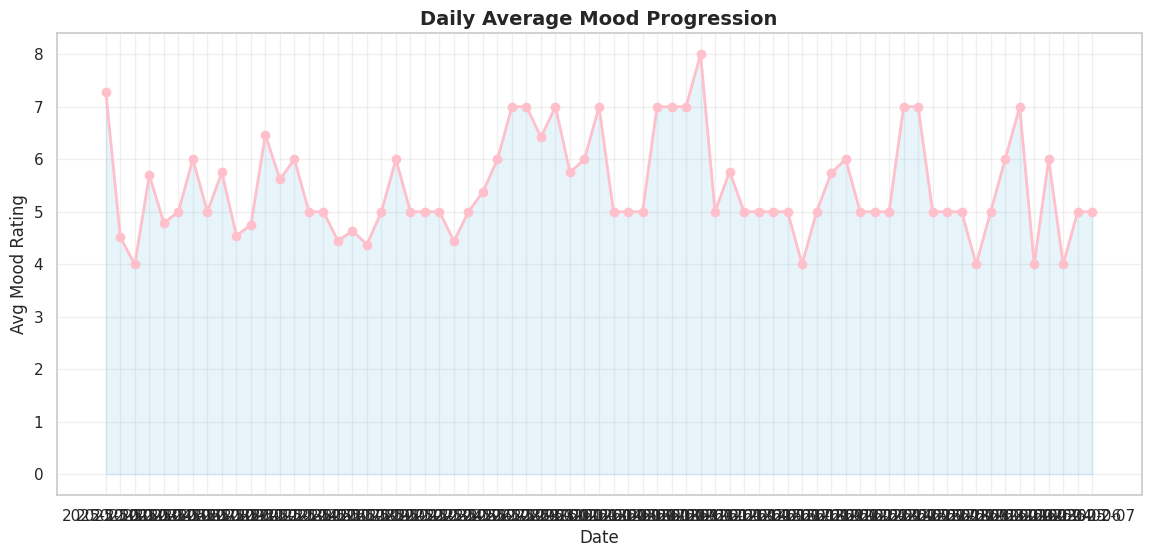

In [17]:
# MOOD TREND OVER THE STUDY PERIOD
# To show if my mood improved or declined
plt.figure(figsize=(14, 6))
daily_mood = df.groupby('Listening_Date')['Mood_Now'].mean()
plt.plot(daily_mood.index, daily_mood.values, marker='o', linestyle='-', color='pink', linewidth=2)
plt.fill_between(daily_mood.index, daily_mood.values, alpha=0.2, color='skyblue')
plt.title('Daily Average Mood Progression', fontweight='bold', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Avg Mood Rating')
plt.grid(True, alpha=0.3)
plt.show()

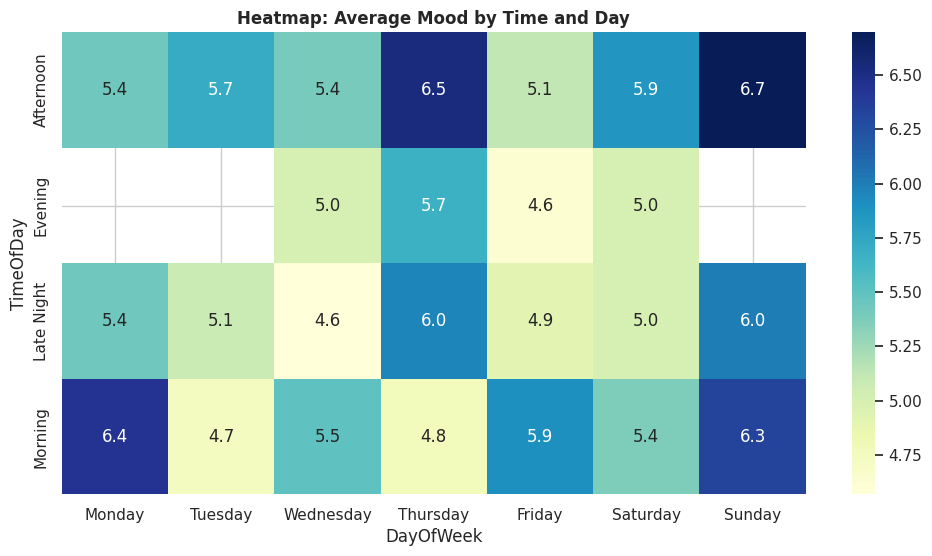

In [19]:
# HEATMAP: MOOD BY TIME OF DAY & DAY OF WEEK

# Ensure 'Listening_Date' is datetime and extract 'DayOfWeek'
df['Listening_Date'] = pd.to_datetime(df['Listening_Date'])
df['DayOfWeek'] = df['Listening_Date'].dt.day_name()

pivot_table = df.pivot_table(index='TimeOfDay', columns='DayOfWeek', values='Mood_Now', aggfunc='mean')
# Reordering columns to follow Monday-Sunday
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot_table = pivot_table.reindex(columns=days_order)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt=".1f")
plt.title('Heatmap: Average Mood by Time and Day', fontweight='bold')
plt.show()

# INFERENTIAL STATISTICS

In [20]:
# STATISTICAL TESTING & ASSUMPTIONS

print("--- 1. ASSUMPTION CHECK: NORMALITY (Shapiro-Wilk) ---")
# Testing if Mood_Now follows a normal distribution
stat, p_norm = stats.shapiro(df['Mood_Now'])
print(f"P-value: {p_norm:.4f}")
if p_norm < 0.05:
    print("Insight: Mood data is not perfectly normal (Common in real-world human data).")

print("\n--- 2. ASSUMPTION CHECK: HOMOGENEITY (Levene's Test) ---")
# Testing if the variance of mood is equal across all 5 genres
genre_groups = [df[df['Genre'] == g]['Mood_Now'] for g in df['Genre'].unique()]
stat_l, p_lev = stats.levene(*genre_groups)
print(f"P-value: {p_lev:.4f}")

print("\n--- 3. HYPOTHESIS TEST: ONE-WAY ANOVA ---")
# Research Question: Does the Genre significantly impact the Mood rating?
# H0: There is no difference in mood across genres.
# H1: At least one genre results in a significantly different mood.
f_stat, p_anova = stats.f_oneway(*genre_groups)

results_table = pd.DataFrame([{
    "Dependent Var": "Mood_Now",
    "Independent Var": "Genre",
    "Test": "One-Way ANOVA",
    "F-Statistic": f"{f_stat:.2f}",
    "P-Value": f"{p_anova:.4f}",
    "Significant": p_anova < 0.05
}])
display(results_table)

--- 1. ASSUMPTION CHECK: NORMALITY (Shapiro-Wilk) ---
P-value: 0.0000
Insight: Mood data is not perfectly normal (Common in real-world human data).

--- 2. ASSUMPTION CHECK: HOMOGENEITY (Levene's Test) ---
P-value: 0.0000

--- 3. HYPOTHESIS TEST: ONE-WAY ANOVA ---


,Dependent Var,Independent Var,Test,F-Statistic,P-Value,Significant
0,Mood_Now,Genre,One-Way ANOVA,12.35,0.0000,True


# MODELING

In [21]:
# (RANDOM FOREST)

# Feature Selection
# Used both music metrics (Valence/Energy) and context (Activity/Time)
features = ['Genre', 'Activity', 'TimeOfDay', 'Valence', 'Energy', 'Hour']
X = df[features]
y = df['Mood_Category'] # Categorical target: Low, Neutral, High

# Stratified Split
# Ensures the training and testing sets have the same ratio of High/Low moods
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Modular Preprocessing
# This handles the different data types automatically within the pipeline
num_cols = ['Valence', 'Energy', 'Hour']
cat_cols = ['Genre', 'Activity', 'TimeOfDay']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

# Final Pipeline Object
model_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42))
])

# Model Evaluation (Cross-Validation)
cv_scores = cross_val_score(model_pipeline, X_train, y_train, cv=StratifiedKFold(5))
model_pipeline.fit(X_train, y_train)

print(f"Average Cross-Validation Accuracy: {cv_scores.mean():.4f}")
print("\n--- Final Test Set Evaluation ---")
print(classification_report(y_test, model_pipeline.predict(X_test)))

Average Cross-Validation Accuracy: 0.8614

--- Final Test Set Evaluation ---
              precision    recall  f1-score   support

        High       0.80      1.00      0.89         4
         Low       0.89      0.47      0.62        34
     Neutral       0.88      0.98      0.92       130

    accuracy                           0.88       168
   macro avg       0.85      0.82      0.81       168
weighted avg       0.88      0.88      0.86       168



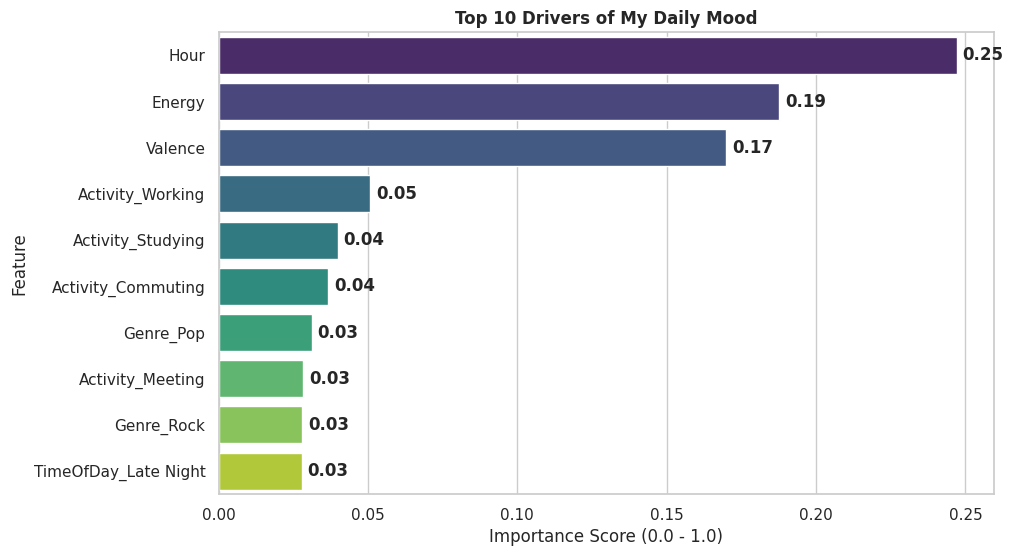

PRESENTATION KEYPOINT: The most significant predictor of your mood is 'Hour'.


In [23]:
# FEATURE IMPORTANCE ANALYSIS

# Extract Feature Names from the Pipeline
cat_names = model_pipeline.named_steps['prep'].named_transformers_['cat'].get_feature_names_out(cat_cols)
all_feature_names = num_cols + list(cat_names)

# Get Importance Scores
importances = model_pipeline.named_steps['model'].feature_importances_
importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot Top 10 Predictors
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='viridis')

# Adding labels for the presentation
for i, v in enumerate(importance_df['Importance'].head(10)):
    plt.text(v + 0.002, i, f'{v:.2f}', va='center', fontweight='bold')

plt.title('Top 10 Drivers of My Daily Mood', fontweight='bold', fontsize=12)
plt.xlabel('Importance Score (0.0 - 1.0)')
plt.show()

# Final Presentation Insight
top_driver = importance_df.iloc[0]['Feature']
print(f"PRESENTATION KEYPOINT: The most significant predictor of your mood is '{top_driver}'.")